In [25]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import shepp_logan_phantom
from skimage.transform import radon, resize, iradon
import skimage
import scipy
import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchmetrics

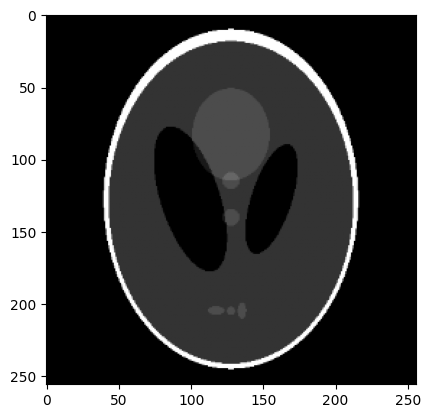

In [7]:
size = 256

phantom = shepp_logan_phantom()
phantom = resize(phantom, (size, size))

plt.imshow(phantom, cmap='gray')
plt.show()

In [852]:
phantom = tum_im[0][0].detach().numpy().copy()

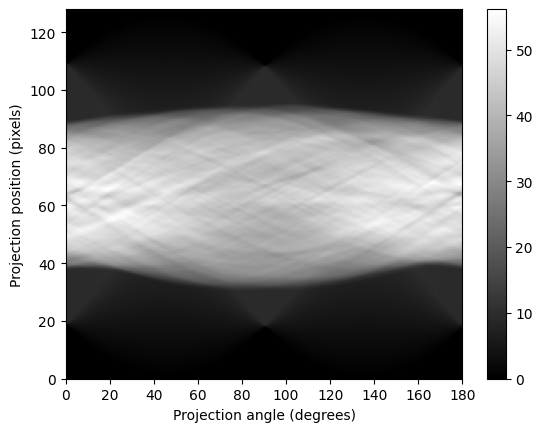

In [886]:
angles = np.linspace(0., 180., 360, endpoint=False)
sinogram = radon(phantom, theta=angles, circle=False)

plt.imshow(sinogram, cmap='gray', extent=(0, 180, 0, phantom.shape[0]), aspect='auto')
plt.xlabel('Projection angle (degrees)')
plt.ylabel('Projection position (pixels)')
plt.colorbar()
plt.show()

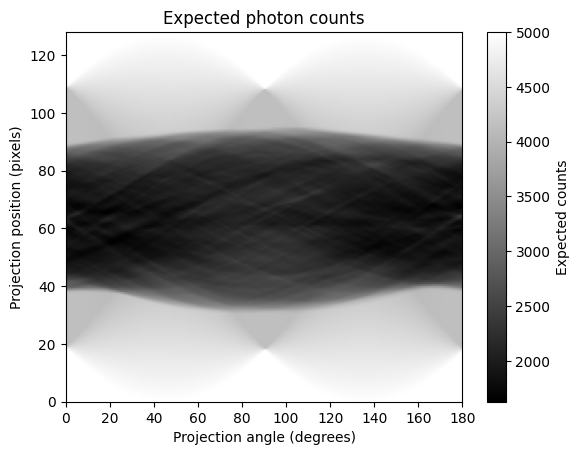

In [866]:
I0 = 5e3
expected_counts = I0 * np.exp(-0.02 * sinogram)
plt.imshow(expected_counts, cmap='gray', extent=(0, 180, 0, phantom.shape[0]), aspect='auto')
plt.xlabel('Projection angle (degrees)')
plt.ylabel('Projection position (pixels)')
plt.title('Expected photon counts')
plt.colorbar(label='Expected counts')
plt.show()

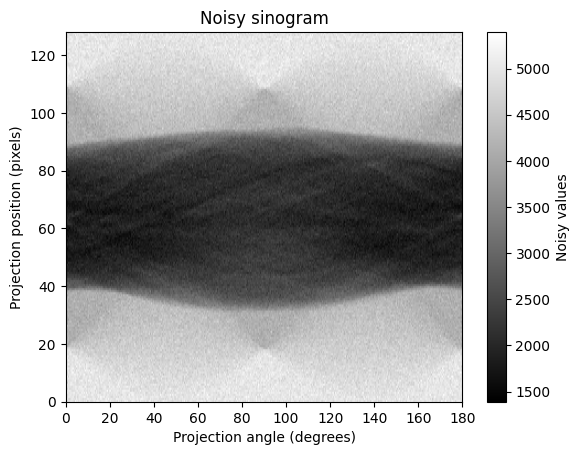

In [885]:
measured_counts = np.random.poisson(expected_counts) + np.random.normal(0, 100, expected_counts.shape)
measured_counts[measured_counts <= 0] = 1
noisy_sinogram = -np.log(measured_counts/I0)

plt.imshow(measured_counts, cmap='gray', extent=(0, 180, 0, phantom.shape[0]), aspect='auto')
plt.xlabel('Projection angle (degrees)')
plt.ylabel('Projection position (pixels)')
plt.title('Noisy sinogram')
plt.colorbar(label='Noisy values')
plt.show()

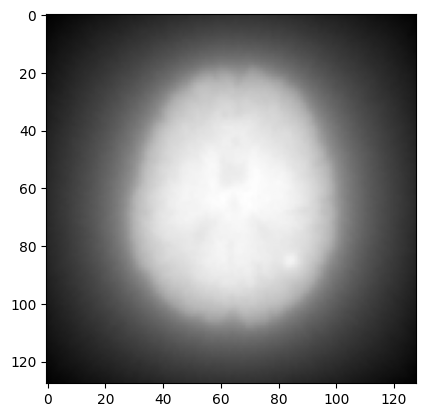

In [868]:
backprojection_reconstruction = iradon(noisy_sinogram, theta=angles, circle=False, filter_name=None)

plt.imshow(backprojection_reconstruction, cmap='gray')
plt.show()

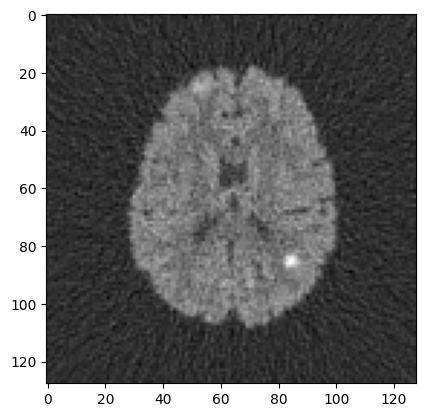

In [869]:
ramp_backprojection_reconstruction = iradon(noisy_sinogram, theta=angles, circle= False, filter_name='ramp')

plt.imshow(ramp_backprojection_reconstruction, cmap='gray')
plt.show()

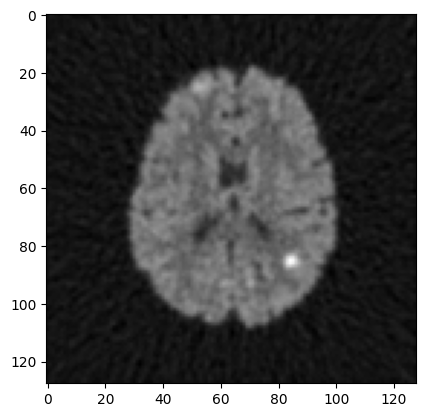

In [870]:
hamming_backprojection_reconstruction = iradon(noisy_sinogram, theta=angles, circle= False, filter_name='hamming')

plt.imshow(hamming_backprojection_reconstruction, cmap='gray')
plt.show()

In [ ]:
def forward_project(image, I0 = 1e4):
    angles = np.linspace(0., 180., 360, endpoint=False)
    sinogram = radon(image, theta=angles, circle=False)
    expected_counts = I0 * np.exp(-0.02 * sinogram)
    measured_counts = np.random.poisson(expected_counts) + np.random.normal(0, 100, expected_counts.shape)
    measured_counts[measured_counts <= 0] = 1
    return measured_counts

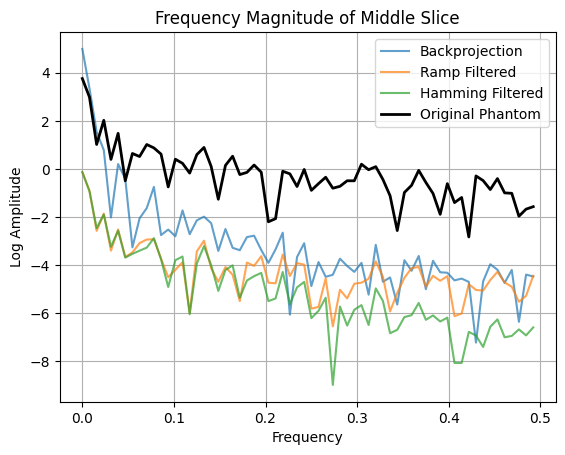

In [860]:
def freq_magnitude_middle(image):
    size = image.shape[0]
    middle_slice = image[size//2, :]
    F = np.fft.fft(middle_slice)
    frequencies = np.fft.fftfreq(len(middle_slice))
    mask = frequencies >= 0
    return frequencies[mask], np.log(np.abs(F[mask]))

freqs_backprojection, mag_backprojection = freq_magnitude_middle(backprojection_reconstruction)
freqs_ramp, mag_ramp = freq_magnitude_middle(ramp_backprojection_reconstruction)
freqs_hamming, mag_hamming = freq_magnitude_middle(hamming_backprojection_reconstruction)
real_freqs, real_mag = freq_magnitude_middle(phantom)

plt.plot(freqs_backprojection, mag_backprojection, label='Backprojection', alpha=0.7)
plt.plot(freqs_ramp, mag_ramp, label='Ramp Filtered', alpha=0.7)
plt.plot(freqs_hamming, mag_hamming, label='Hamming Filtered', alpha=0.7)
plt.plot(real_freqs, real_mag, label='Original Phantom', color='black', linewidth=2)
plt.title('Frequency Magnitude of Middle Slice')
plt.xlabel('Frequency')
plt.ylabel('Log Amplitude')
plt.grid()
plt.legend()
plt.show()

In [163]:
def compute_psnr(original, reconstructed):
    return skimage.metrics.peak_signal_noise_ratio(original, reconstructed, data_range=1.0)

def compute_ssim(original, reconstructed):
    return skimage.metrics.structural_similarity(original, reconstructed, data_range=1.0)

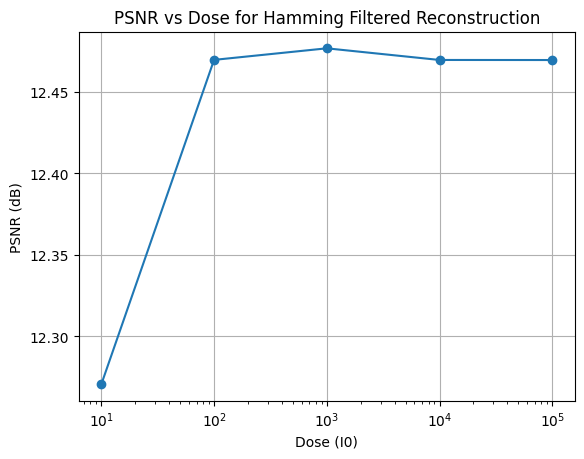

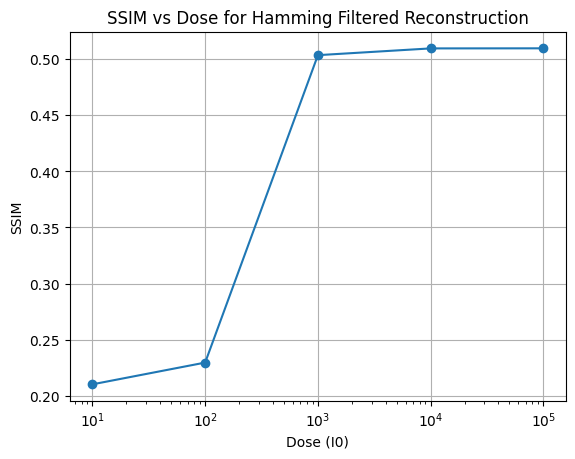

In [165]:
psnrs = []
ssims = []
for dose in range(1,6):
    I0 = 10**dose
    expected_counts = I0 * np.exp(-0.02 * sinogram)
    measured_counts = np.random.poisson(expected_counts) + np.random.normal(0, 100, expected_counts.shape)
    measured_counts[measured_counts <= 0] = 1
    noisy_sinogram = -np.log(measured_counts/I0)
    
    hamming_backprojection_reconstruction = iradon(noisy_sinogram, theta=angles, circle= False, filter_name='hamming')
    psnrs.append(compute_psnr(phantom, hamming_backprojection_reconstruction))
    ssims.append(compute_ssim(phantom, hamming_backprojection_reconstruction))
    

plt.plot([10**dose for dose in range(1,6)], psnrs, marker='o')
plt.xscale('log')
plt.xlabel('Dose (I0)')
plt.ylabel('PSNR (dB)')
plt.title('PSNR vs Dose for Hamming Filtered Reconstruction')
plt.grid()
plt.show()
plt.plot([10**dose for dose in range(1,6)], ssims, marker='o')
plt.xscale('log')
plt.xlabel('Dose (I0)')
plt.ylabel('SSIM')
plt.title('SSIM vs Dose for Hamming Filtered Reconstruction')
plt.grid()
plt.show()

In [6]:
csf1 = plt.imread('images/1/1_csf.gif')
gry1 = plt.imread('images/1/1_gry.gif')
wht1 = plt.imread('images/1/1_wht.gif')

weights = [0.299, 0.587, 0.114]

im1 = 0.1 * csf1 + 0.4 * gry1 + 0.25 * wht1
g_im1 = np.dot(im1[...,:3], weights)
plt.imshow(g_im1, cmap='gray')

FileNotFoundError: [Errno 2] No such file or directory: 'images/1/1_csf.gif'

In [798]:
def grayscale(image):
    weights = [0.299, 0.587, 0.114]
    return np.dot(image[...,:3], weights)

def create_image(csf,wht,gry, alpha=5, sigma=100):
    csf = grayscale(csf)
    wht = grayscale(wht)
    gry = grayscale(gry)
    shape = csf.shape
    dx = np.random.randn(shape[0], shape[1])
    dy = np.random.randn(shape[0], shape[1])
    dx = scipy.ndimage.gaussian_filter(dx, sigma) * alpha
    dy = scipy.ndimage.gaussian_filter(dy, sigma) * alpha
    x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
    indices_x = x + dx
    indices_y = y + dy
    deformed_csf = scipy.ndimage.map_coordinates(csf, [indices_y, indices_x], order=5, mode='reflect')
    deformed_wht = scipy.ndimage.map_coordinates(wht, [indices_y, indices_x], order=5, mode='reflect')
    deformed_gry = scipy.ndimage.map_coordinates(gry, [indices_y, indices_x], order=5, mode='reflect')
    angle = np.random.uniform(-5, 5)
    deformed_image = scipy.ndimage.rotate(deformed_csf, angle, reshape=False, order=5, mode='reflect')
    deformed_wht = scipy.ndimage.rotate(deformed_wht, angle, reshape=False, order=5, mode='reflect')
    deformed_gry = scipy.ndimage.rotate(deformed_gry, angle, reshape=False, order=5, mode='reflect')
    scale = np.random.uniform(0.9, 1.1)
    deformed_csf = scipy.ndimage.zoom(deformed_csf, scale, order=5)
    deformed_wht = scipy.ndimage.zoom(deformed_wht, scale, order=5)
    deformed_gry = scipy.ndimage.zoom(deformed_gry, scale, order=5)
    deformed_image = np.random.normal(0.1, 0.025) * deformed_csf + np.random.normal(0.4, 0.025) * deformed_gry + np.random.normal(0.25, 0.025) * deformed_wht
    if scale > 1.0:
        start = (deformed_image.shape[0] - shape[0]) // 2
        deformed_image = deformed_image[start:start+shape[0], start:start+shape[1]]
    else:
        pad_width = (shape[0] - deformed_image.shape[0]) // 2
        deformed_image = np.pad(deformed_image, pad_width, mode='reflect')
        deformed_image = deformed_image[:shape[0], :shape[1]]
    deformed_image = deformed_image[:128,:128]
    deformed_image -= np.min(deformed_image)
    deformed_image /= np.max(deformed_image)
    return deformed_image

def create_tumor_image(csf,wht,gry, alpha=5, sigma=100):
    csf = grayscale(csf)
    wht = grayscale(wht)
    gry = grayscale(gry)
    shape = csf.shape
    dx = np.random.randn(shape[0], shape[1])
    dy = np.random.randn(shape[0], shape[1])
    dx = scipy.ndimage.gaussian_filter(dx, sigma) * alpha
    dy = scipy.ndimage.gaussian_filter(dy, sigma) * alpha
    x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
    mu_x = np.clip(np.random.randn() + 0.5, 0.35, 0.65)
    mu_y = np.clip(np.random.randn() + 0.5, 0.35, 0.65)
    size = np.random.randn()* 0.32 + 1.5
    tumor = np.exp(-((x - mu_x * shape[1]) ** 2 + (y - mu_y * shape[0]) ** 2) / (2 * size ** 2))
    indices_x = x + dx
    indices_y = y + dy
    deformed_csf = scipy.ndimage.map_coordinates(csf, [indices_y, indices_x], order=5, mode='reflect')
    deformed_wht = scipy.ndimage.map_coordinates(wht, [indices_y, indices_x], order=5, mode='reflect')
    deformed_gry = scipy.ndimage.map_coordinates(gry, [indices_y, indices_x], order=5, mode='reflect')
    deformed_tum = scipy.ndimage.map_coordinates(tumor, [indices_y, indices_x], order=5, mode='reflect')
    angle = np.random.uniform(-5, 5)
    deformed_image = scipy.ndimage.rotate(deformed_csf, angle, reshape=False, order=5, mode='reflect')
    deformed_wht = scipy.ndimage.rotate(deformed_wht, angle, reshape=False, order=5, mode='reflect')
    deformed_gry = scipy.ndimage.rotate(deformed_gry, angle, reshape=False, order=5, mode='reflect')
    deformed_tum = scipy.ndimage.rotate(deformed_tum, angle, reshape=False, order=5, mode='reflect')
    scale = np.random.uniform(0.9, 1.1)
    deformed_csf = scipy.ndimage.zoom(deformed_csf, scale, order=5)
    deformed_wht = scipy.ndimage.zoom(deformed_wht, scale, order=5)
    deformed_gry = scipy.ndimage.zoom(deformed_gry, scale, order=5)
    deformed_tum = scipy.ndimage.zoom(deformed_tum, scale, order=5)
    deformed_image = np.random.normal(0.1, 0.025) * deformed_csf + np.random.normal(0.4, 0.025) * deformed_gry + np.random.normal(0.25, 0.025) * deformed_wht
    if scale > 1.0:
        start = (deformed_image.shape[0] - shape[0]) // 2
        deformed_image = deformed_image[start:start+shape[0], start:start+shape[1]]
        deformed_tum = deformed_tum[start:start+shape[0], start:start+shape[1]]
    else:
        pad_width = (shape[0] - deformed_image.shape[0]) // 2
        deformed_image = np.pad(deformed_image, pad_width, mode='reflect')
        deformed_image = deformed_image[:shape[0], :shape[1]]
        deformed_tum = np.pad(deformed_tum, pad_width, mode='reflect')
        deformed_tum = deformed_tum[:shape[0], :shape[1]]
    deformed_tum = deformed_tum[:128,:128]
    deformed_tum -= np.min(deformed_tum)
    deformed_tum /= np.max(deformed_tum)
    deformed_tum[deformed_tum < 0.2] = 0
    deformed_image = deformed_image[:128,:128]
    deformed_image -= np.min(deformed_image)
    deformed_image /= np.max(deformed_image)
    
    return deformed_image, deformed_tum
#healthy_image = create_healthy_image(csf1, gry1, wht1)
#plt.imshow(deformation(healthy_image), cmap='gray')

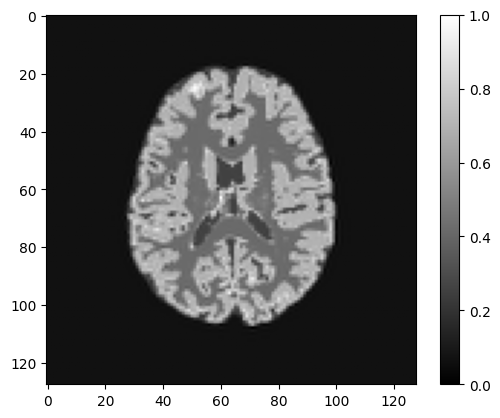

In [589]:
csf = plt.imread('images/1_csf.gif')
wht = plt.imread('images/1_wht.gif')
gry = plt.imread('images/1_gry.gif')

plt.imshow(create_image(csf,wht,gry), cmap='gray')
plt.colorbar()

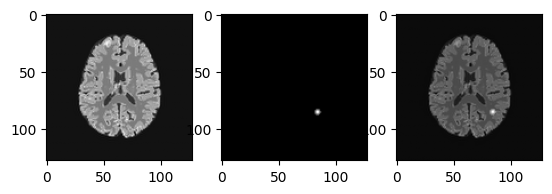

In [818]:
im, tum = create_tumor_image(csf,wht,gry)
plt.subplot(1,3,1)
plt.imshow(im, cmap='gray')
plt.subplot(1,3,2)
plt.imshow(tum, cmap='gray')
plt.subplot(1,3,3)
plt.imshow(im+tum, cmap='gray')

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [01:21<00:00,  4.09s/it]


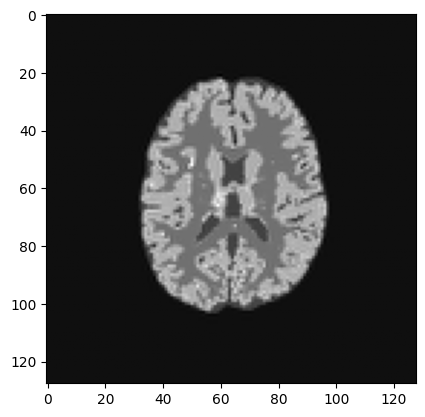

In [3]:
images = []
for i in tqdm.tqdm(range(1,21)):
    csf = plt.imread(f'images/{i}_csf.gif')
    gry = plt.imread(f'images/{i}_gry.gif')
    wht = plt.imread(f'images/{i}_wht.gif')
    for _ in range(100):
        images.append(create_image(csf,wht,gry))
plt.imshow(images[-1], cmap='gray')
plt.show()

(128, 128)

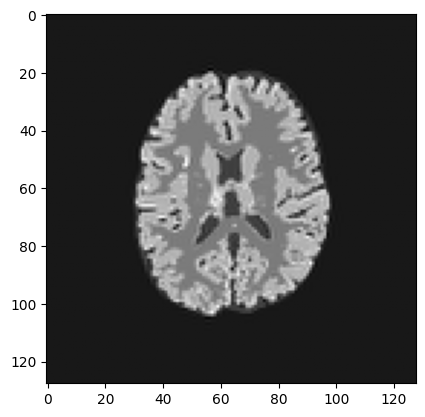

In [34]:
ima = images[-1].copy()
ima = ima[:128,:128]
plt.imshow(ima, cmap='gray')
ima.shape

In [ ]:
images = np.array(images)
images = torch.tensor(images, dtype=torch.float32)
images = images.unsqueeze(1)
dataset = torch.utils.data.TensorDataset(images)
loader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)

/var/folders/0h/4w8rfwxs61qgv4g_zt_0ll_80000gn/T/ipykernel_76774/1597673941.py:1: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  images = torch.tensor(images, dtype=torch.float32)


In [10]:


class VAE(nn.Module):

    def __init__(self, latent_dim = 64):
        super().__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32,64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.ReLU()
        )

        self.fc_mean = nn.Linear(256*8*8, self.latent_dim)
        self.fc_log_var = nn.Linear(256*8*8, self.latent_dim)

        self.fc_decode = nn.Linear(self.latent_dim, 256*8*8)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def reparametrize(self, mean, logvar):
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)
        return mean + std * epsilon
    
    def encode(self, x):
        x = self.encoder(x)
        x = x.view(x.size(0), -1)
        mean = self.fc_mean(x)
        logvar = self.fc_log_var(x)
        return mean, logvar
    
    def decode(self, z):
        x = self.fc_decode(z)
        x = x.view(x.size(0), 256, 8, 8)
        x = self.decoder(x)
        return x
    
    def forward(self, x):
        mean, logvar = self.encode(x)
        z = self.reparametrize(mean, logvar)
        reconstruction = self.decode(z)
        return reconstruction, mean, logvar


In [135]:
def image_gradient(image):
    dx = image[:,:,:,1:] - image[:,:,:,:-1]
    dy = image[:,:,1:,:] - image[:,:,:-1,:]
    return dx, dy

def gradient_loss(reconstruction, x):
    dx, dy = image_gradient(reconstruction)
    dx_gt, dy_gt = image_gradient(x)
    loss = F.mse_loss(dx, dx_gt) + F.mse_loss(dy, dy_gt)
    return loss

def vae_loss(reconstruction, x, mean, logvar, beta=0.00001):
    mse = F.mse_loss(reconstruction, x)
    kl_loss = -0.5 * torch.sum(1 + logvar - mean.pow(2) - logvar.exp()) 
    #structure_loss = 1 - torchmetrics.functional.structural_similarity_index_measure(reconstruction, x)
    grad_loss = gradient_loss(reconstruction, x)
    total_loss = mse + beta * kl_loss  + 0.1 * grad_loss# + 0.1 * structure_loss
    return total_loss#, mse, kl_loss, structure_loss, grad_loss

In [136]:
model = VAE(latent_dim = 64)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

epochs = 25
beta = 0.01

for epoch in tqdm.tqdm(range(epochs)):
    model.train()

    total_loss = 0
    total_mse = 0
    total_kl = 0
    structure_loss = 0
    grad_loss = 0

    for batch in loader:
        x = batch[0]
        reconstruction, mean, logvar = model(x)
        #loss, mse, kl, structure, grad = vae_loss(reconstruction, x, mean, logvar, beta)
        loss = vae_loss(reconstruction, x, mean, logvar, beta)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        '''total_mse += mse.item()
        total_kl += kl.item()
        structure_loss += structure
        grad_loss += grad'''

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(loader)}")#, MSE: {total_mse/len(loader)}, KL: {total_kl/len(loader)}, Structure: {structure_loss/len(loader)}, Grad: {grad_loss/len(loader)}")

  4%|▍         | 1/25 [00:12<04:50, 12.09s/it]

Epoch 1/25, Loss: 0.12127400118680227


  8%|▊         | 2/25 [00:23<04:33, 11.90s/it]

Epoch 2/25, Loss: 0.050953533382169784


 12%|█▏        | 3/25 [00:35<04:16, 11.66s/it]

...

Epoch 23/25, Loss: 0.012636232810715834


 96%|█████████▌| 24/25 [05:07<00:13, 13.64s/it]

Epoch 24/25, Loss: 0.01260470822157841


100%|██████████| 25/25 [05:21<00:00, 12.86s/it]

Epoch 25/25, Loss: 0.01254887915852051


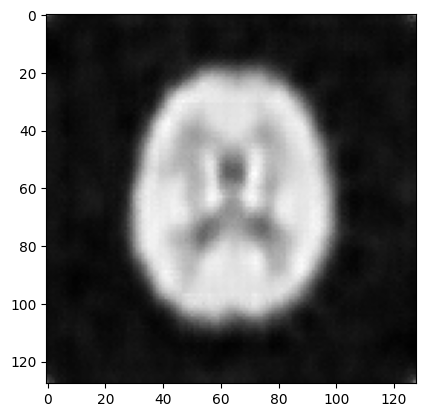

In [137]:
model.eval()
with torch.no_grad():
    z = torch.randn(1, 64)
    gen = model.decode(z)
    plt.imshow(gen[0][0], cmap='gray')
    plt.show()

/var/folders/0h/4w8rfwxs61qgv4g_zt_0ll_80000gn/T/ipykernel_76774/3174350378.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test = torch.tensor(test).unsqueeze(0)


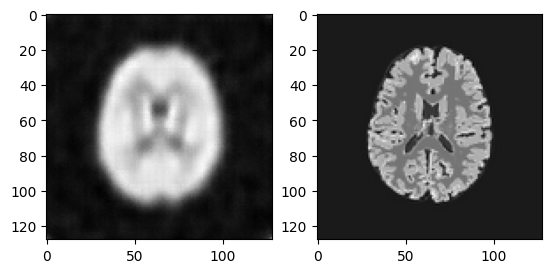

In [144]:
with torch.no_grad():
    test = images[9]
    test = torch.tensor(test).unsqueeze(0)
    reconstruction, mean, logvar = model(test)
    plt.subplot(1,2,1)
    plt.imshow(reconstruction[0][0], cmap='gray')
    plt.subplot(1,2,2)
    plt.imshow(test[0][0], cmap='gray')

In [148]:
class CNNRefiner(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(1,32,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.Conv2d(32,32,kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.Conv2d(32,32,kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.Conv2d(32,1,kernel_size = 3, padding = 1),
            nn.ReLU()
        )
    def forward(self, x):
        res = self.network(x)
        refined = res + x
        return refined

In [149]:
cnn = CNNRefiner()
optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-4)

epochs = 20
for epoch in tqdm.tqdm(range(epochs)):
    for batch in loader:
        x = batch[0]
        with torch.no_grad():
            recon,_,_ = model(x)
        refinement = cnn(recon)
        mse_loss = F.mse_loss(refinement, x)
        grad_loss = gradient_loss(refinement, x)
        loss = mse_loss + 0.1 * grad_loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

100%|██████████| 20/20 [21:39<00:00, 64.97s/it]


/var/folders/0h/4w8rfwxs61qgv4g_zt_0ll_80000gn/T/ipykernel_76774/3415296669.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test = torch.tensor(test).unsqueeze(0)


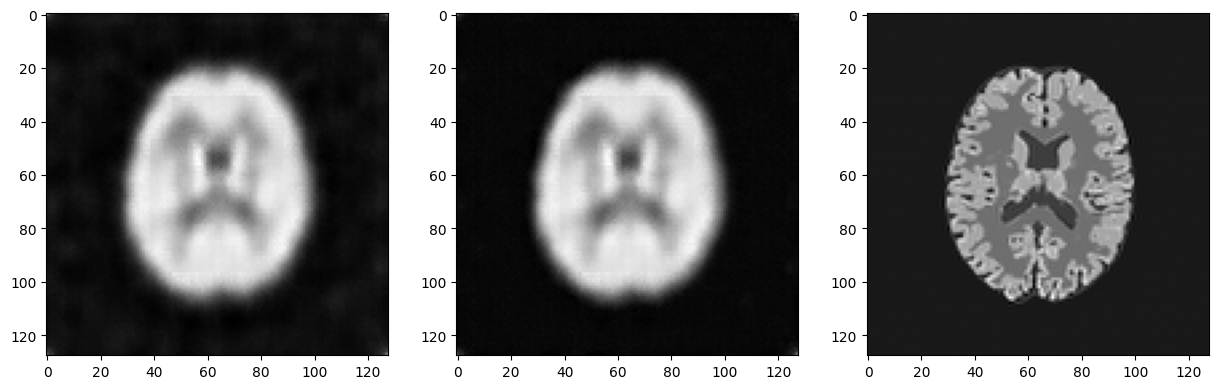

In [162]:
with torch.no_grad():
    test = images[np.random.randint(0, len(images))]
    test = torch.tensor(test).unsqueeze(0)
    reconstruction, mean, logvar = model(test)
    refined = cnn(reconstruction)
    plt.figure(figsize=(15,5))
    plt.subplot(1,3,1)
    plt.imshow(reconstruction[0][0], cmap='gray')
    plt.subplot(1,3,2)
    plt.imshow(refined[0][0], cmap='gray')
    plt.subplot(1,3,3)
    plt.imshow(test[0][0], cmap='gray')

In [892]:
class AutoEncoder(nn.Module):
    def __init__(self, latent_dim = 64):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32,64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.ReLU()
        )
        self.fc_encode = nn.Linear(256*8*8, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, 256*8*8)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        z = self.encoder(x)
        z = z.view(z.size(0), -1)
        z = self.fc_encode(z)
        return z
    
    def decode(self, z):
        x = self.fc_decode(z)
        x = x.view(x.size(0), 256, 8, 8)
        x = self.decoder(x)
        return x
    
    def forward(self,x):
        z = self.encode(x)
        reconstruction = self.decode(z)
        return reconstruction
    
class LatentDiscriminator(nn.Module):
    def __init__(self, latent_dim = 64):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128,128),
            nn.ReLU(),
            nn.Linear(128,1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

In [ ]:
ae = AutoEncoder(latent_dim = 64)
disc = LatentDiscriminator(latent_dim = 64)

ae_optimizer = torch.optim.Adam(ae.parameters(), lr=1e-4)
disc_optimizer = torch.optim.Adam(disc.parameters(), lr=1e-4)

epochs = 25

ae.train()
disc.train()
for epoch in tqdm.tqdm(range(epochs)):
    tdisc_loss = 0
    trec_loss = 0
    tadv_loss = 0

    for batch in loader:
        x = batch[0]
        z_real = torch.randn(x.size(0), 64)
        z_enc = ae.encode(x).detach()
        pred_real = disc(z_real)
        pred_enc = disc(z_enc)
        real_loss = F.binary_cross_entropy(pred_real, torch.ones_like(pred_real))
        enc_loss = F.binary_cross_entropy(pred_enc, torch.zeros_like(pred_enc))
        disc_loss = real_loss + enc_loss
        disc_optimizer.zero_grad()
        disc_loss.backward()
        disc_optimizer.step()

        for p in disc.parameters():
            p.requires_grad = False
        
        z_enc = ae.encode(x)
        pred_enc = disc(z_enc)
        reconstruction = ae.decode(z_enc)
        rec_loss = F.mse_loss(reconstruction, x) +  gradient_loss(reconstruction, x) + (1 - torchmetrics.functional.structural_similarity_index_measure(reconstruction, x))
        adv_loss = F.binary_cross_entropy(pred_enc, torch.ones_like(pred_enc))
        ae_loss = rec_loss + 0.01 * adv_loss
        ae_optimizer.zero_grad()
        ae_loss.backward()
        ae_optimizer.step()

        for p in disc.parameters():
            p.requires_grad = True

        tdisc_loss += disc_loss
        trec_loss += rec_loss
        tadv_loss += adv_loss
    print(f"Epoch {epoch+1}/{epochs}, Discriminator Loss: {tdisc_loss/len(loader)}, Reconstruction Loss: {trec_loss/len(loader)}, Adversarial Loss: {tadv_loss/len(loader)}")


  4%|▍         | 1/25 [00:37<14:48, 37.03s/it]

Epoch 1/25, Discriminator Loss: 0.02347046695649624, Reconstruction Loss: 0.018281450495123863, Adversarial Loss: 0.07451815903186798


  8%|▊         | 2/25 [01:17<14:59, 39.11s/it]

Epoch 2/25, Discriminator Loss: 0.0381169393658638, Reconstruction Loss: 0.012409626506268978, Adversarial Loss: 0.04305635765194893


 12%|█▏        | 3/25 [02:01<15:08, 41.28s/it]

...

Epoch 23/25, Discriminator Loss: 0.039610907435417175, Reconstruction Loss: 0.006784297525882721, Adversarial Loss: 0.029395591467618942


 96%|█████████▌| 24/25 [14:15<00:34, 34.21s/it]

Epoch 24/25, Discriminator Loss: 0.034593451768159866, Reconstruction Loss: 0.007311064284294844, Adversarial Loss: 0.027555175125598907


100%|██████████| 25/25 [14:49<00:00, 35.60s/it]

Epoch 25/25, Discriminator Loss: 0.03811783343553543, Reconstruction Loss: 0.007277015596628189, Adversarial Loss: 0.0260896235704422


/var/folders/0h/4w8rfwxs61qgv4g_zt_0ll_80000gn/T/ipykernel_76774/1333056146.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test = torch.tensor(test).unsqueeze(0)


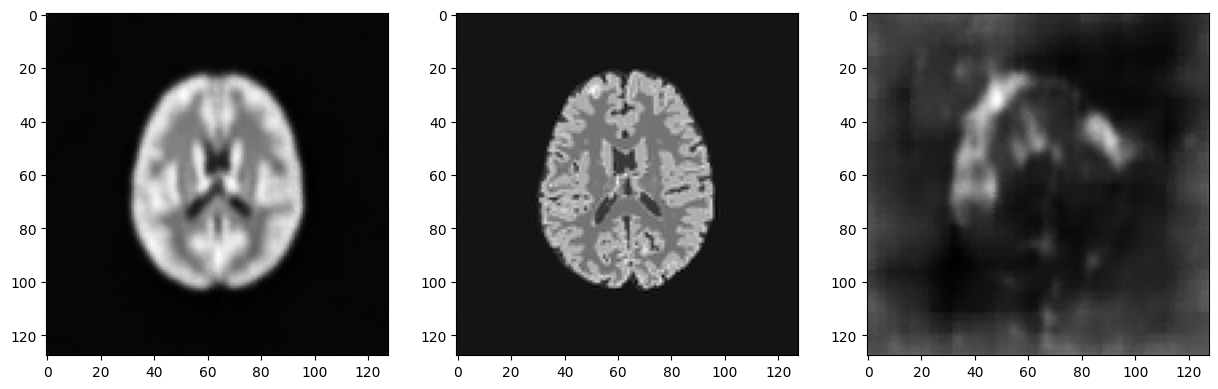

In [273]:
with torch.no_grad():
    test = images[np.random.randint(0, len(images))]
    test = torch.tensor(test).unsqueeze(0)
    z = ae.encode(test)
    reconstruction = ae.decode(z)
    z_prime = torch.randn(1, 64)
    plt.figure(figsize=(15,5))
    plt.subplot(1,3,1)
    plt.imshow(reconstruction[0][0], cmap='gray')
    plt.subplot(1,3,2)
    plt.imshow(test[0][0], cmap='gray')
    plt.subplot(1,3,3)
    plt.imshow(ae.decode(z_prime)[0][0], cmap = 'gray')

In [274]:
ae = AutoEncoder()
disc = LatentDiscriminator()

epochs = 25
ae.train()
for epoch in tqdm.tqdm(range(epochs)):
    total_ae_loss = 0
    for batch in loader:
        x = batch[0]
        reconstruction = ae(x)
        loss = F.mse_loss(reconstruction, x) + gradient_loss(reconstruction, x) + (1 - torchmetrics.functional.structural_similarity_index_measure(reconstruction, x))
        ae_optimizer.zero_grad()
        loss.backward()
        ae_optimizer.step()
        total_ae_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_ae_loss/len(loader)}")

  0%|          | 0/25 [00:00<?, ?it/s]/Users/rayenezanina/Desktop/Project/medical image reconstruction/.venv/lib/python3.14/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(
  4%|▍         | 1/25 [00:30<12:21, 30.92s/it]

Epoch 1/25, Loss: 0.934108659388527


  8%|▊         | 2/25 [01:00<11:32, 30.12s/it]

Epoch 2/25, Loss: 0.9340448048379686


 12%|█▏        | 3/25 [01:36<12:01, 32.79s/it]

...

Epoch 23/25, Loss: 0.9341251358153329


 96%|█████████▌| 24/25 [12:15<00:30, 30.86s/it]

Epoch 24/25, Loss: 0.9340799290036398


100%|██████████| 25/25 [12:53<00:00, 30.92s/it]

Epoch 25/25, Loss: 0.9341822162507072


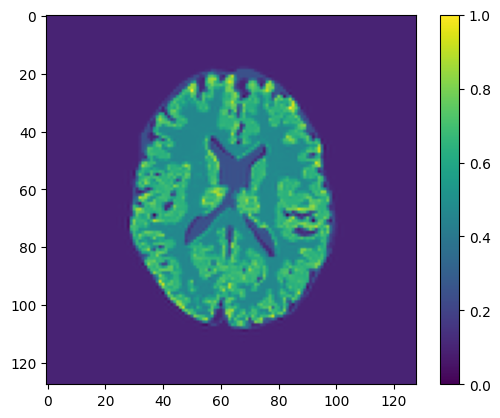

In [ ]:
ae.eval()
with torch.no_grad():
    x = images[np.random.randint(0, len(images))]
        recon = ae(torch.tensor(x).unsqueeze(0))
        plt.imshow(recon[0][0], cmap='gray')
        plt.show()

In [ ]:
ae_state_dict = torch.load('models/ae_trained.pth', map_location=torch.device('cpu'))
disc_state_dict = torch.load('models/disc_trained.pth', map_location=torch.device('cpu'))
trained_ae = AutoEncoder(latent_dim=128)
trained_ae.load_state_dict(ae_state_dict)
trained_disc = LatentDiscriminator(latent_dim=128)
trained_disc.load_state_dict(disc_state_dict)

<All keys matched successfully>

(128, 128)
tensor(1.8810)


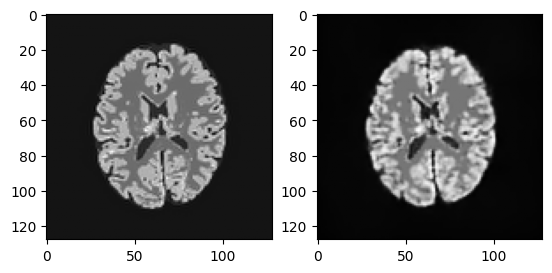

In [464]:
ae.eval()
i = np.random.randint(1,21)
csf = plt.imread(f'images/{i}_csf.gif')
gry = plt.imread(f'images/{i}_gry.gif')
wht = plt.imread(f'images/{i}_wht.gif')
src_img = create_image(csf, wht, gry)
print(src_img.shape)
with torch.no_grad():
    x = torch.tensor(src_img).unsqueeze(0).unsqueeze(0).float()
    z = trained_ae.encode(x)
    z_new = z + torch.randn_like(z) * 0.15
    x_gen = trained_ae.decode(z_new)
    plt.subplot(1,2,1)
    plt.imshow(src_img, cmap='gray')
    plt.subplot(1,2,2)
    plt.imshow(x_gen[0][0], cmap='gray')
    print(torch.norm(z_new - z))

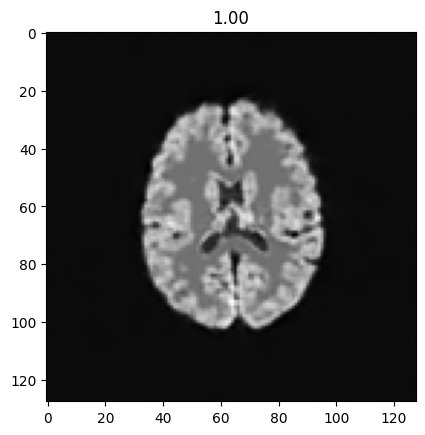

In [484]:
from IPython.display import clear_output
with torch.no_grad():
    im1 = images[np.random.randint(0, len(images))]
    im2 = images[np.random.randint(0, len(images))]

    im1 = torch.tensor(im1).unsqueeze(0)
    im2 = torch.tensor(im2).unsqueeze(0)

    z1 = trained_ae.encode(im1)
    z2 = trained_ae.encode(im2)

    for a in torch.linspace(0,1,20):
        z = a * z1 + (1-a) * z2
        plt.imshow(trained_ae.decode(z)[0][0], cmap='gray')
        plt.title(f'{a:.2f}')
        plt.show()
        plt.pause(0.5)
        clear_output(wait=True)

In [486]:
latents = []
with torch.no_grad():
    for batch in loader:
        x = batch[0].float().cpu()
        z = trained_ae.encode(x)
        latents.append(z)
z = torch.cat(latents, dim=0).numpy()
z.shape

(2000, 128)

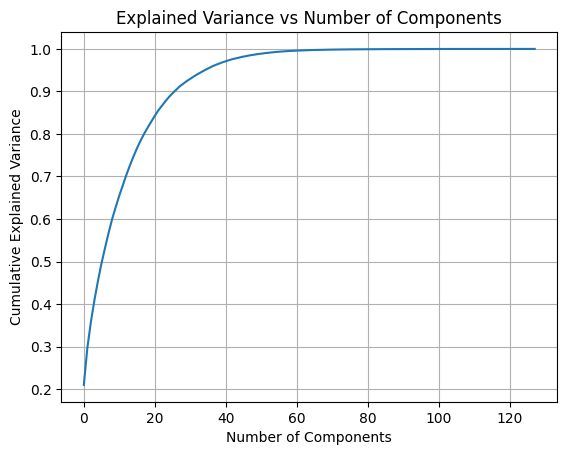

In [488]:
from sklearn.decomposition import PCA

pca = PCA()
z_pca = pca.fit_transform(z)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs Number of Components')
plt.grid(True)

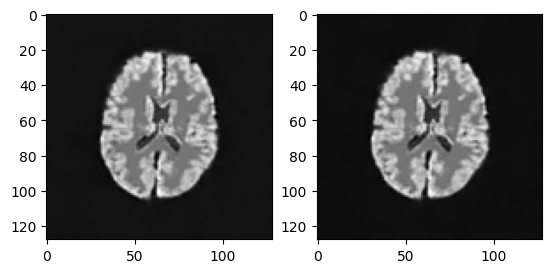

In [520]:

pca = PCA(n_components = 40)
z_pca = pca.fit_transform(z)
lat = z[0].copy()
pca_lat = pca.transform([lat])
z_lat = pca.inverse_transform(pca_lat)
z_lat = torch.tensor(z_lat, dtype=torch.float32).unsqueeze(0).cpu()
plt.subplot(1,2,1)
plt.imshow(trained_ae.decode(z_lat)[0][0].detach(), cmap='gray')
plt.subplot(1,2,2)
plt.imshow(trained_ae.decode(torch.tensor(lat, dtype=torch.float32).unsqueeze(0).cpu()).detach().numpy()[0][0], cmap='gray')


In [887]:
np.sum(pca_lat)

np.float64(-14.45517539813206)

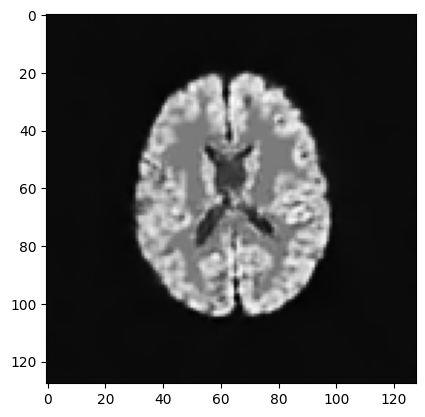

In [587]:
z_pca_gen = np.random.randn(40) * np.sqrt(pca.explained_variance_)
z_gen = pca.inverse_transform([z_pca_gen])
z_gen = torch.tensor(z_gen, dtype=torch.float32).unsqueeze(0).cpu()
plt.imshow(trained_ae.decode(z_gen)[0][0].detach(), cmap='gray')

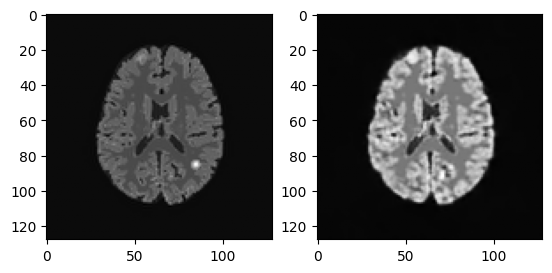

In [823]:
tum_im = im+tum
tum_im = torch.tensor(tum_im).unsqueeze(0).unsqueeze(0).float().cpu()
reconstructed_tum = trained_ae(tum_im)
plt.subplot(1,2,1)
plt.imshow(tum_im[0][0], cmap='gray')
plt.subplot(1,2,2)
plt.imshow(reconstructed_tum[0][0].detach(), cmap='gray')

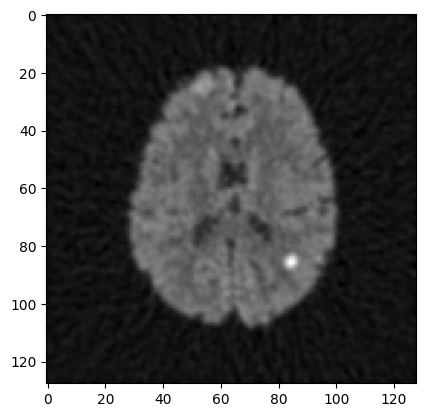

In [871]:
sino = forward_project(tum_im[0][0], I0 = 5e3)
plt.imshow(iradon(sino,circle=False, filter_name = 'hamming'), cmap='gray')

In [880]:
pca_mean = torch.tensor(pca.mean_, dtype=torch.float32)
pca_components = torch.tensor(pca.components_, dtype=torch.float32)

def decode_pca(c):
    z = pca_mean + pca_components.T @ c
    recon = trained_ae.decode(z.unsqueeze(0))
    return recon

def forward_model(c, res):
    x = decode_pca(c) + res
    Ax = forward_project(x[0][0].detach().numpy())
    Ax = torch.tensor(Ax, dtype=torch.float32)
    return Ax

def poisson_loss(Ax, y):
    eps = 1e-8
    return (Ax - y * torch.log(Ax + eps)).sum()

def objective(c, r, y, lam_r = 0.001):
    Ax = forward_model(c, r)
    data_validity = poisson_loss(Ax, y)
    sparsity = lam_r * torch.abs(r).sum()
    return data_validity + sparsity

c = torch.zeros(pca_components.shape[0], requires_grad=True)
r = torch.zeros((1,1,128,128), requires_grad=True)

opt_c = torch.optim.Adam([c], lr = 1e-2)
opt_r = torch.optim.Adam([r], lr = 1e-2)

  4%|▍         | 1/25 [00:04<01:36,  4.00s/it]

Global Epoch: 0, Loss: nan


  8%|▊         | 2/25 [00:07<01:30,  3.94s/it]

Global Epoch: 1, Loss: nan


 12%|█▏        | 3/25 [00:11<01:26,  3.93s/it]

...

Global Epoch: 22, Loss: nan


 96%|█████████▌| 24/25 [01:38<00:03,  3.95s/it]

Global Epoch: 23, Loss: nan


100%|██████████| 25/25 [01:42<00:00,  4.09s/it]

Global Epoch: 24, Loss: nan


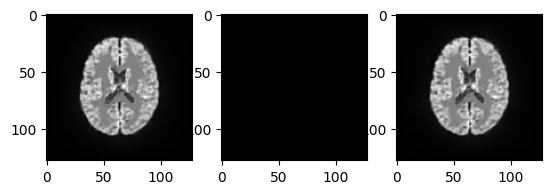

In [ ]:
y_measured = forward_project(tum_im[0][0], I0 = 5e3)
y_measured = torch.tensor(y_measured, dtype=torch.float32)

global_epochs = 25
inner_epochs = 20

for g_epoch in tqdm.tqdm(range(global_epochs)):
    for _ in range(inner_epochs):
        opt_c.zero_grad()
        loss = objective(c,r,y_measured)
        loss.backward()
        opt_c.step()
    for _ in range(inner_epochs):
        opt_r.zero_grad()
        loss = objective(c,r,y_measured)
        loss.backward()
        opt_r.step()

        with torch.no_grad():
            threshold = 1e-2
            r.data = torch.sign(r.data) * torch.clamp(torch.abs(r.data) - threshold, min=0)
    print(f'Global Epoch: {g_epoch}, Loss: {loss.item()}')

with torch.no_grad():
    plt.subplot(1,4,1)
    plt.imshow(decode_pca(c)[0][0].detach(), cmap='gray')
    plt.subplot(1,4,2)
    plt.imshow(r[0][0].detach(), cmap='gray')
    plt.subplot(1,4,3)
    plt.imshow(decode_pca(c)[0][0] + r[0][0], cmap='gray')
    plt,subplot(1,4,4)
    plt.imshow(tum_im[0][0], cmap='gray')




In [890]:
device = torch.device('mps')

In [895]:
tumor_images = []
healthy_images = []

for i in range(1, 21):
    csf = plt.imread(f'images/{i}_csf.gif')
    gry = plt.imread(f'images/{i}_gry.gif')
    wht = plt.imread(f'images/{i}_wht.gif')
    for _ in range(100):
        img, tum = create_tumor_image(csf, wht, gry)
        tumor_images.append(tum)
        healthy_images.append(img)

tumor_images = torch.tensor(tumor_images).float().to(device)
healthy_images = torch.tensor(healthy_images).float().to(device)

In [896]:

tum_dataset = torch.utils.data.TensorDataset(tumor_images)
tum_loader = torch.utils.data.DataLoader(tum_dataset, batch_size=32, shuffle=True)

In [897]:
tumor_ae = AutoEncoder(latent_dim = 16).to(device)

def image_gradient(image):
    dx = image[:,:,:,1:] - image[:,:,:,:-1]
    dy = image[:,:,1:,:] - image[:,:,:-1,:]
    return dx, dy

def gradient_loss(reconstruction, x):
    dx, dy = image_gradient(reconstruction)
    dx_gt, dy_gt = image_gradient(x)
    loss = F.mse_loss(dx, dx_gt) + F.mse_loss(dy, dy_gt)
    return loss

tumor_opt = torch.optim.Adam(tumor_ae.parameters(), lr=1e-4)

In [ ]:
epochs = 100
tumor_ae.train()
for epoch in tqdm.tqdm(range(epochs)):
    total_ae_loss = 0
    for batch in loader:
        x = batch[0].to(device)
        reconstruction = tumor_ae(x)
        loss = F.mse_loss(reconstruction, x) + gradient_loss(reconstruction, x) + (1 - torchmetrics.functional.structural_similarity_index_measure(reconstruction, x))
        tumor_opt.zero_grad()
        loss.backward()
        tumor_opt.step()
        total_ae_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_ae_loss/len(loader)}")

  0%|          | 0/100 [00:00<?, ?it/s]/Users/rayenezanina/Desktop/Project/medical image reconstruction/.venv/lib/python3.14/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(
  1%|          | 1/100 [00:10<17:44, 10.75s/it]

Epoch 1/100, Loss: 0.8087037981502594


  2%|▏         | 2/100 [00:16<12:17,  7.53s/it]

Epoch 2/100, Loss: 0.42394122055598665


  3%|▎         | 3/100 [00:21<10:29,  6.49s/it]

Epoch 3/100, Loss: 0.29633388443598674


  3%|▎         | 3/100 [00:22<12:13,  7.56s/it]


KeyboardInterrupt: 